# **Seventh LangGraph**

## **Boilerplate**

In [15]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ["OPENAI_API_KEY"]:
    print("OpenAI api key set")
else:
    raise ValueError("OpenAI api key is not set")

OpenAI api key set


In [16]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

## **Pydantic Schema (for LLM)**

In [17]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    platform: Literal['insta', 'twitter', 'linkedin'] = Field(description="the platform for which to generate the post")
    topic: str = Field(description="the topic of the post to be generated")

In [18]:
llm_with_schema = llm.with_structured_output(llm_schema)

llm_with_schema.invoke("I want to generate a post for twitter about ai")

llm_schema(platform='twitter', topic='AI advancements and their impact on society')

## **State Schema**

In [19]:
from typing import TypedDict, Annotated
import operator

class graph_schema(TypedDict):

    input: str
    platform: str
    topic: str
    post: str

## **Create Graph Nodes**

In [ ]:
def decider_node(state: graph_schema) -> graph_schema:

    input = state['input']

    response = llm_with_schema.invoke(f"decide which platform should be used and what the topic should be for this post based on: {input}")

    state['platform'] = response.platform
    state['topic'] = response.topic

    return state

def create_post_insta(state: graph_schema) -> graph_schema:

    topic = state['topic']

    post = llm.invoke(f"write an instagram post about {topic}").content
    
    state['post'] = post

    return state

def create_post_twitter(state: graph_schema) -> graph_schema:

    topic = state['topic']

    post = llm.invoke(f"write a twitter post about {topic}").content

    state['post'] = post

    return state

def create_post_linkedin(state: graph_schema) -> graph_schema:

    topic = state['topic']

    post = llm.invoke(f"write a linkedin post about {topic}").content

    state['post'] = post

    return state

## **Condition For the Conditional Edges**

In [21]:
def condition(state: graph_schema) -> str:

    platform = state['platform']

    if platform == 'insta': return 'create_post_insta'
    elif platform == 'twitter': return 'create_post_twitter'
    elif platform == 'linkedin': return 'create_post_linkedin'
    else: raise ValueError("Invalid platform")

## **Create Graph w/ Parallel Nodes**

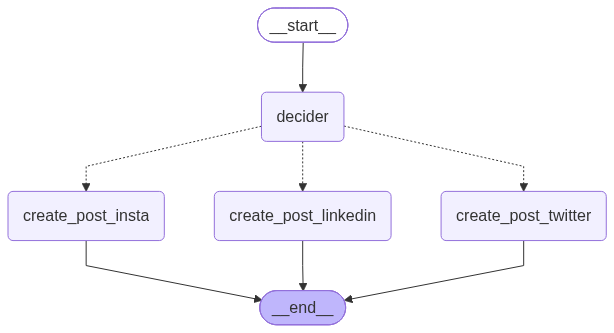

In [27]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

# add conditional edges:
graph.add_edge(START, "decider")
graph.add_conditional_edges("decider", condition, {"create_post_insta": "create_post_insta", "create_post_linkedin": "create_post_linkedin", "create_post_twitter": "create_post_twitter"})
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

# compile graph
route_graph = graph.compile()

# display graph
from IPython.display import Image, display

Image(route_graph.get_graph().draw_mermaid_png())




## **Invoke Graph**

In [28]:
route_graph.invoke({
    "input": "I want to write a twitter post about ai.",
    "topic": "",
    "platform": "",
    "post": ""
})

{'input': 'I want to write a twitter post about ai.',
 'platform': 'twitter',
 'topic': 'AI Innovations and Future Trends',
 'post': ''}